<a href="https://colab.research.google.com/github/Kris01655/Mineria-de-Datos/blob/main/EV1_Sismologia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EXPLORACIÓN DE DATOS SÍSMICOS DE CHILE 2012-2025
        
## 🧠Cómo la minería de datos se aplica en los movimientos telúricos de Chile
        
Autores del notebook: -Francisca Otárola - Kristyn Hernandez.
        
Fecha: abril 2026
        
Objetivo: Evaluación 1, el análisis de los datos sísmicos reales de manera exploratoria, aspirando a exponer de manera concreta y estadística los sismos de Chile
        
Datasets utilizados
        
[Earthquakes on Chile](https://drive.google.com/file/d/1f3b08Pon_w3CnjI4frQRRjCrDXxEyA-H/view?usp=drive_link) —** Centro Sismológico de Chile

[sismos_data.csv](https://drive.google.com/file/d/1f3b08Pon_w3CnjI4frQRRjCrDXxEyA-H/view?usp=drive_link)

Columnas agregadas

[Comunas](https://drive.google.com/file/d/1kpXFjriGJo0VQBNjXYYx2GU86rr5tKLu/view?usp=drive_link)**

[Región](https://drive.google.com/file/d/1BtGooAnsFCUDTPV5taCvHKGNmhKmylOa/view?usp=drive_link)**

Herramientas Necesarias
*   Pandas as pd
*   Numpy as np
*   Matplotlib.pyplot as plt
*   Seaborn as sns
*   geopandas as gpd

Dataframes importados
*   df = pd.read_csv('sismos_data.csv')
*   gdf_regiones = gpd.read_file('regiones.geojson')
*   gdf_comunas = gpd.read_file('comunas.geojson')
*   gdf_sismos = gpd.GeoDataFrame(df,geometry=gpd.points_from_xy(df ['Longitude'], df['Latitude']),
    crs='EPSG:4326')
Repositorio en GitHub

1.Conocer la Data.

En esta parte, realizamos la carga inicial del dataset de sismos y exploramos su estructura basica.

In [ ]:
import pandas as pd #usamos panda para la manipulacion y estructuracion de los datos en el dataframe.
import numpy as np #usamos numpy para hacer las operaciones matematicas y numericas.
import matplotlib.pyplot as plt #usamos matplotlib y seaborn para generar visualizaciones grafiscas.
import seaborn as sns

In [ ]:
#carga de datos
df = pd.read_csv('sismos_data.csv')

In [ ]:
#visualizamos las 5 primeras filas
df.head(5)

,Date(UTC),Latitude,Longitude,Depth,Magnitude
0,2025-05-26 03:50:27,-19.63,-69.49,97,5.6
1,2025-05-13 00:47:58,-51.25,-72.28,28,5.1
2,2025-05-05 09:46:48,-29.49,-71.84,48,5.0
3,2025-05-05 02:17:48,-31.89,-70.88,88,5.1
4,2025-05-02 15:23:49,-27.52,-72.48,30,5.8


In [ ]:
#visualizamos las 5 ultimas filas
df.tail(5)

,Date(UTC),Latitude,Longitude,Depth,Magnitude
4013,2012-03-24 07:28:33,-33.05,-71.06,69,5.2
4014,2012-03-19 21:52:39,-25.00,-69.75,100,5.0
4015,2012-03-10 02:26:57,-19.74,-69.25,101,5.3
4016,2012-03-04 16:27:20,-21.60,-70.06,47,5.3
4017,2012-03-03 11:01:47,-30.19,-71.45,35,5.6


In [ ]:
#ver cantidad de filas y columnas
df.shape

(4018, 5)

In [ ]:
#ver tipos de datos de las columnas
df.dtypes

,0
Date(UTC),object
Latitude,float64
Longitude,float64
Depth,int64
Magnitude,float64


In [ ]:
#aqui nos aseguramos de que el dataset contenga nulos
df.isnull().sum()

,0
Date(UTC),0
Latitude,0
Longitude,0
Depth,0
Magnitude,0


In [ ]:
df.columns

Index(['Date(UTC)', 'Latitude', 'Longitude', 'Depth', 'Magnitude'], dtype='object')

Para lograr el analisis, importamos los datasets necesarios utilizando las librerias de pandas y geopandas y en esta parte tenemos tres fuentes de datos (sismos_data.csv), (regiones.geojson) y (comunas.geojson).

In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
#aqui cargo los archivos
df = pd.read_csv('sismos_data.csv')#esto contiene el registro de los eventos sismicos
gdf_regiones = gpd.read_file('regiones.geojson')#estos archivos geoespaciales nos dejaran hacer
gdf_comunas = gpd.read_file('comunas.geojson')#la union geografica para asociar cada sismo en su ubicacion correspondiente.

Una vez que los datos se cargaron podemos transformar nuestro dataframe original en un geodataframe. Con este geodataframe podemos tomar las coordenadas geograficas (Latitud, Longitud) utilizando la referencia de coordenadas EPSG:4326.
Con esto permitiendonos realizar la ubicacion de los sismos.

In [ ]:
#convertimos a geodataframe
gdf_sismos = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df['Longitude'], df['Latitude']),
    crs='EPSG:4326'
)

Tras integrar los datos realizamos un print para verificar si hay existencia de datos nulos, y el resultado fue un 0 lo que confirma la integridad del dataset, esto nos garantiza que contamos con una base de datos limpia y asi podemos seguir con nuestro analisis estadistico.


In [ ]:
print("Nulos en el dataset original:", df.isnull().sum().sum())

Nulos en el dataset original: 0


Aqui realizamos la union espacial de nuestros sismos con los datos geograficos, este proceso es vital para atribuir cada eventp con su contexto territorial (sus respectivas regiones y comunas). utilizamos un left join con las regiones y comunas para asignar la ubicacion de cada sismo basado en su geometria. Tambien renombramos las variables para estandarizar el dataset(Date a Fecha) facilitando su interpretacion.
Y para los valores nulos (los sismos que ocurren en el mar) aplicamos un imput donde los valores nulos fueron etiquetados como mar/oceano.

In [ ]:
# Union Regiones
sismos_unido = gpd.sjoin(gdf_sismos, gdf_regiones[['geometry', 'Region']], how="left", predicate="within")
# limpiar el índice inmediatamente después de la primera unión
sismos_unido = sismos_unido.drop(columns=['index_right'], errors='ignore')
# Union Comunas
sismos_final = gpd.sjoin(sismos_unido, gdf_comunas[['geometry', 'Comuna']], how="left", predicate="within")
# Limpiar el índice de esta segunda unión
sismos_final = sismos_final.drop(columns=['index_right'], errors='ignore')
# Limpieza de nombres
sismos_final = sismos_final.rename(columns={
    'Date(UTC)': 'Fecha',
    'Depth': 'Profundidad',
    'Magnitude': 'Magnitud',
    'Latitude': 'Latitud',
    'Longitude': 'Longitud'
})

# Rellenar nulos ya que existen lugares en el mar donde se registran sismos.
sismos_final['Region'] = sismos_final['Region'].fillna('Mar/Oceano')
sismos_final['Comuna'] = sismos_final['Comuna'].fillna('Mar/Oceano')

# verifico nulos
print("Nulos después de la unión espacial:")
print(sismos_final[['Region', 'Comuna']].isnull().sum())

Nulos después de la unión espacial:
Region    0
Comuna    0
dtype: int64


Despues de la union y el cambio de nulos, hacemos un print para ver las primeras 5 filas del nuevo dataset.

In [ ]:
print(sismos_final.head())

                 Fecha  Latitud  Longitud  Profundidad  Magnitud  \
0  2025-05-26 03:50:27   -19.63    -69.49           97       5.6   
1  2025-05-13 00:47:58   -51.25    -72.28           28       5.1   
2  2025-05-05 09:46:48   -29.49    -71.84           48       5.0   
3  2025-05-05 02:17:48   -31.89    -70.88           88       5.1   
4  2025-05-02 15:23:49   -27.52    -72.48           30       5.8   

                geometry                                    Region  \
0  POINT (-69.49 -19.63)                        Región de Tarapacá   
1  POINT (-72.28 -51.25)  Región de Magallanes y Antártica Chilena   
2  POINT (-71.84 -29.49)                                Mar/Oceano   
3  POINT (-70.88 -31.89)                        Región de Coquimbo   
4  POINT (-72.48 -27.52)                                Mar/Oceano   

             Comuna  
0             Huara  
1  Torres del Paine  
2        Mar/Oceano  
3         Salamanca  
4        Mar/Oceano  


Aqui hice un print para visualizar mejor la tabla.

In [ ]:
#tabla limpia para la evaluacion
columnas_interes = ['Fecha', 'Magnitud', 'Region', 'Comuna']
print(sismos_final[columnas_interes].head(10).to_string())

                 Fecha  Magnitud                                    Region                Comuna
0  2025-05-26 03:50:27       5.6                        Región de Tarapacá                 Huara
1  2025-05-13 00:47:58       5.1  Región de Magallanes y Antártica Chilena      Torres del Paine
2  2025-05-05 09:46:48       5.0                                Mar/Oceano            Mar/Oceano
3  2025-05-05 02:17:48       5.1                        Región de Coquimbo             Salamanca
4  2025-05-02 15:23:49       5.8                                Mar/Oceano            Mar/Oceano
5  2025-05-02 12:58:32       7.5                                Mar/Oceano            Mar/Oceano
6  2025-04-24 03:20:08       5.4                                Mar/Oceano            Mar/Oceano
7  2025-04-18 00:10:18       6.0                     Región de Antofagasta  San Pedro de Atacama
8  2025-04-08 22:30:45       5.2                        Región de Tarapacá                  Pica
9  2025-04-08 10:28:43       4

Con el objetivo de mejorar la visibilidad y el analisis temporal realizamos un proceso para la columna Fecha, convertimos el formato datetime a dos variables independientes: Fecha(dia, mes, año) y Hora. Tambien nos aseguramos de que las variables Latitud, Longitud y geometry se mantuvieran sin ningun cambio tras el reordenamiento.

In [ ]:
#cambio en fecha le agregare la hora
sismos_final['Fecha'] = pd.to_datetime(sismos_final['Fecha'])

#cree la columna hora
sismos_final['Hora'] = sismos_final['Fecha'].dt.time

#aqui tuve que sobreescribir la columna fehca para que solo tenga la fecha
sismos_final['Fecha'] = sismos_final['Fecha'].dt.date

#aqui la reordeno para que se vea mas bonito
columnas_ordenadas = ['Fecha', 'Hora', 'Magnitud', 'Region', 'Comuna']

#se mantienen las columnas restantes como latitud y longitud
otras_cols = [c for c in sismos_final.columns if c not in columnas_ordenadas]
sismos_final = sismos_final[columnas_ordenadas + otras_cols]

#resultado
print(sismos_final.head())


        Fecha      Hora  Magnitud                                    Region  \
0  2025-05-26  03:50:27       5.6                        Región de Tarapacá   
1  2025-05-13  00:47:58       5.1  Región de Magallanes y Antártica Chilena   
2  2025-05-05  09:46:48       5.0                                Mar/Oceano   
3  2025-05-05  02:17:48       5.1                        Región de Coquimbo   
4  2025-05-02  15:23:49       5.8                                Mar/Oceano   

             Comuna  Latitud  Longitud  Profundidad               geometry  
0             Huara   -19.63    -69.49           97  POINT (-69.49 -19.63)  
1  Torres del Paine   -51.25    -72.28           28  POINT (-72.28 -51.25)  
2        Mar/Oceano   -29.49    -71.84           48  POINT (-71.84 -29.49)  
3         Salamanca   -31.89    -70.88           88  POINT (-70.88 -31.89)  
4        Mar/Oceano   -27.52    -72.48           30  POINT (-72.48 -27.52)  


In [ ]:
#aqui exportamos el Dataset limpio
sismos_final.to_csv('sismos_final.csv', index=False)

Para poder manejar mejor la data, se restrablecieron los dataframe y se concatenaron las columnas, mostrando el resultado final

In [ ]:
# Restablecemos el índice de sismos_final antes de concatenar con gdf_regiones.
sismos_final_reset = sismos_final.reset_index(drop=True) # restablecemos el index de sismos final
gdf_regiones_reset = gdf_regiones.reset_index(drop=True) # restablecemos el index de regiones

# Eliminamos la columna de geometry de sismos_final_reset para poder concatenar sin problemas.
sismos_final_no_geom = sismos_final_reset.drop(columns=['geometry'], errors='ignore')

# Concatenamos el dataFrame sin region y sin geometry con el one-hot encoder de las regiones codificadas.
df_final = pd.concat([sismos_final_no_geom.drop(columns=['Region'], errors='ignore'), gdf_regiones_reset], axis=1)

df_final.head() # mostramos el resultado

,Fecha,Hora,Magnitud,Comuna,Latitud,Longitud,Profundidad,area_km,objectid,cir_sena,st_area_sh,codregion,st_length_,Region,geometry
0,2025-05-26,03:50:27,5.6,Huara,-19.63,-69.49,97,16866.8198,1084.0,1.0,1.886869e+10,15.0,7.505296e+05,Región de Arica y Parinacota,"POLYGON ((-69.4153 -17.6552, -69.3366 -17.7322..."
1,2025-05-13,00:47:58,5.1,Torres del Paine,-51.25,-72.28,28,42284.5674,1085.0,2.0,4.830637e+10,1.0,1.213713e+06,Región de Tarapacá,"MULTIPOLYGON (((-70.1603 -20.2107, -70.1602 -2..."
2,2025-05-05,09:46:48,5.0,Mar/Oceano,-29.49,-71.84,48,126071.4319,1086.0,3.0,1.508452e+11,2.0,2.516112e+06,Región de Antofagasta,"MULTIPOLYGON (((-70.7016 -25.8917, -70.7005 -2..."
3,2025-05-05,02:17:48,5.1,Salamanca,-31.89,-70.88,88,133053.1423,1087.0,15.0,3.581316e+11,12.0,9.049830e+07,Región de Magallanes y Antártica Chilena,"MULTIPOLYGON (((-67.3202 -55.9201, -67.2487 -5..."
4,2025-05-02,15:23:49,5.8,Mar/Oceano,-27.52,-72.48,30,106703.3773,1088.0,14.0,2.242743e+11,11.0,4.144481e+07,Región de Aysén del Gral.Ibañez del Campo,"MULTIPOLYGON (((-75.5799 -48.7589, -75.5803 -4..."


Generamos la estaditica descriptiva en la data de las columnas numericas como magnitud, latitud, longuitud, profundidad, el codigo de region y km.

In [ ]:
# Mostramos estadística descriptiva para las columnas numéricas en df_final
display(df_final.describe())

,Magnitud,Latitud,Longitud,Profundidad,area_km,objectid,cir_sena,st_area_sh,codregion,st_length_
count,4032.000000,4032.000000,4032.000000,4032.000000,17.000000,17.000000,17.000000,1.700000e+01,17.000000,1.700000e+01
mean,4.428522,-27.839720,-70.850848,61.555060,44656.288029,1092.000000,7.647059,7.682654e+10,8.000000,9.458103e+06
std,0.688189,5.961752,1.292103,38.244172,40826.876942,5.049752,4.649478,9.119000e+10,5.049752,2.302917e+07
min,2.300000,-62.350000,-75.730000,2.000000,3937.432000,1084.000000,0.000000,9.306245e+09,0.000000,3.887224e+05
25%,4.000000,-31.820000,-71.590000,36.000000,16349.029900,1088.000000,4.000000,2.301475e+10,4.000000,1.074094e+06
50%,4.400000,-29.615000,-71.180000,50.000000,30321.890600,1092.000000,8.000000,4.596943e+10,8.000000,1.679609e+06
75%,4.800000,-21.505000,-70.030000,86.250000,48408.371300,1096.000000,11.000000,8.771834e+10,12.000000,2.401741e+06
max,8.400000,-11.070000,-58.390000,624.000000,133053.142300,1100.000000,15.000000,3.581316e+11,16.000000,9.049830e+07


Aqui generamos una version limpia del dataset (sismos_final_limpio) y eliminamos a columna geometry de manera visual para asegurar que los datos se vean de una forma estandarizada y eficiente. Aqui estan todas las variables corregidas, listas para ser utilizadas en futuros analisis.


In [ ]:
#elimino la columna solo para que se vea bonito para el csv final
sismos_final_limpio = sismos_final.drop(columns=['geometry'])
#ahora imprimo la tabla
print(sismos_final_limpio.head())

        Fecha      Hora  Magnitud                                    Region  \
0  2025-05-26  03:50:27       5.6                        Región de Tarapacá   
1  2025-05-13  00:47:58       5.1  Región de Magallanes y Antártica Chilena   
2  2025-05-05  09:46:48       5.0                                Mar/Oceano   
3  2025-05-05  02:17:48       5.1                        Región de Coquimbo   
4  2025-05-02  15:23:49       5.8                                Mar/Oceano   

             Comuna  Latitud  Longitud  Profundidad  
0             Huara   -19.63    -69.49           97  
1  Torres del Paine   -51.25    -72.28           28  
2        Mar/Oceano   -29.49    -71.84           48  
3         Salamanca   -31.89    -70.88           88  
4        Mar/Oceano   -27.52    -72.48           30  


ESTADISTICAS

In [ ]:
#aqui imprimimos que columnas tenemos despues de toda la limpieza
print("Nombres de las columnas en el dataset final:")
print(sismos_final.columns.tolist())

Nombres de las columnas en el dataset final:
['Fecha', 'Hora', 'Magnitud', 'Region', 'Comuna', 'Latitud', 'Longitud', 'Profundidad', 'geometry']


MAPEO DE DATOS

Variables Cuantitativas: Magnitud, Profundidad, Latitud, Longitud.

Variables Cualitativas: Region, Comuna.

Variables Temporales: Fecha, Hora.

Geometria: geometry (la usamos para la union espacial).

En esta parte organizamos los datos para ver la magnitud y profundidad promedio de los sismos, agrupamos datos de region y comuna para tener un promedio real de cada zona, tambien redondeamos a dos decimales y organizamos la tabla para que sea mucho mas facil de leer y entender. En conclusion esta tabla nos deja comparar que comunas tienen, en promedio, los sismos mas intensos/produndos.

In [ ]:
#agrupamos redondeamos a 2 decimales ya que la tabla tiene muchos decimales y no se ve muy estetico
resumen_combinado = sismos_final.groupby(['Region', 'Comuna'])[['Magnitud', 'Profundidad']].mean().round(2)
#hacemos un reset al indice para que sea una tabla plana y mucho mas facil de leer
resumen_limpio = resumen_combinado.reset_index()

print("Resumen de Magnitud y Profundidad:")
print(resumen_limpio.head(15).to_string(index=False))


Resumen de Magnitud y Profundidad:
                          Region          Comuna  Magnitud  Profundidad
                      Mar/Oceano         Caldera      4.10        56.00
                      Mar/Oceano        Coquimbo      3.70        52.00
                      Mar/Oceano        La Unión      4.70        42.00
                      Mar/Oceano            Lebu      3.30        20.50
                      Mar/Oceano      Mar/Oceano      4.55        45.81
                      Mar/Oceano        Quintero      4.05        31.50
Región Metropolitana de Santiago           Alhué      4.18        66.75
Región Metropolitana de Santiago Calera de Tango      5.30        92.00
Región Metropolitana de Santiago       Cartagena      4.00        53.00
Región Metropolitana de Santiago          Colina      4.54        86.71
Región Metropolitana de Santiago        Curacaví      4.40        77.00
Región Metropolitana de Santiago        El Monte      4.80        68.00
Región Metropolitana de Santi

Como parte de nuestro analisis, quisimos observar especificamente que sucede en la comuna Pudahuel, lo que hicimos fue seleccionar los registros sismicos asociados a esta comuna y realizamos un resumen estadistico para ver la magnitud y profundidad de los sismos regitrados.

In [ ]:
#filtramos por comuna en este caso elegi Pudahuel
pudahuel_data = sismos_final[sismos_final['Comuna'] == 'Pudahuel']

#verifico rapidamente
print(f"Sismos registrados en Pudahuel: {len(pudahuel_data)}")

#hago una estadística si es que existen registros
if not pudahuel_data.empty:
    print("\nEstadística descriptiva para Pudahuel:")
    # Mostramos Magnitud y Profundidad
    print(pudahuel_data[['Magnitud', 'Profundidad']].describe())
else:
    print("\nNo se encontraron registros de sismos para la comuna de Pudahuel en el dataset.")

#La desviacion estandar (std) aparece cuando varian los datos entre si
#como solo hay un sismo registrado en pudahuel, no hay variacion que calcular,
#por eso el sistema devuelve el valor nulo.

Sismos registrados en Pudahuel: 1

Estadística descriptiva para Pudahuel:
       Magnitud  Profundidad
count       1.0          1.0
mean        4.5         76.0
std         NaN          NaN
min         4.5         76.0
25%         4.5         76.0
50%         4.5         76.0
75%         4.5         76.0
max         4.5         76.0


Para tener una mejor perspectiva analizamos la comuna de Los Andes que a diferencia de Pudahuel, en Los Andes registramos 10 eventos sismicos. Esta comparacion nos muestra que la actividad sismica puede cambiar drasticamente entre una comuna a otra, tanto en cantidad como en comportamiento fisico.

In [ ]:
#filtramos por comuna en este caso elegi Pudahuel
los_andes_data = sismos_final[sismos_final['Comuna'] == 'Los Andes']

#verifico rapidamente
print(f"Sismos registrados en Los Andes: {len(los_andes_data)}")

#hago una estadística si es que existen registros
if not los_andes_data.empty:
    print("\nEstadística descriptiva para Los Andes:")
    # Mostramos Magnitud y Profundidad
    print(los_andes_data[['Magnitud', 'Profundidad']].describe())
else:
    print("\nNo se encontraron registros de sismos para la comuna de Los Andes en el dataset.")
#En Los Andes observamos una mayor actividad sismica (10) en comparacion con la comuna de Pudahuel (1)
#La desviacion estandar es de 42.9 km en la profundidad sugiere una amplia dispersion
#en la ubicacion vertical de los epicentros de esta comuna

Sismos registrados en Los Andes: 10

Estadística descriptiva para Los Andes:
        Magnitud  Profundidad
count  10.000000      10.0000
mean    4.310000      91.7000
std     0.465355      42.9083
min     3.300000       9.0000
25%     4.150000      99.2500
50%     4.350000     111.0000
75%     4.500000     114.0000
max     5.100000     126.0000


El histograma muestra la cantidad de sismos segun su magnitud. La curva nos permite ver rapidamente cual es la intensidad mas comun dentro de los registros. La gran mayoria de los sismos registrados tienen una magnitud de alrededor de 4.2 o 4.3

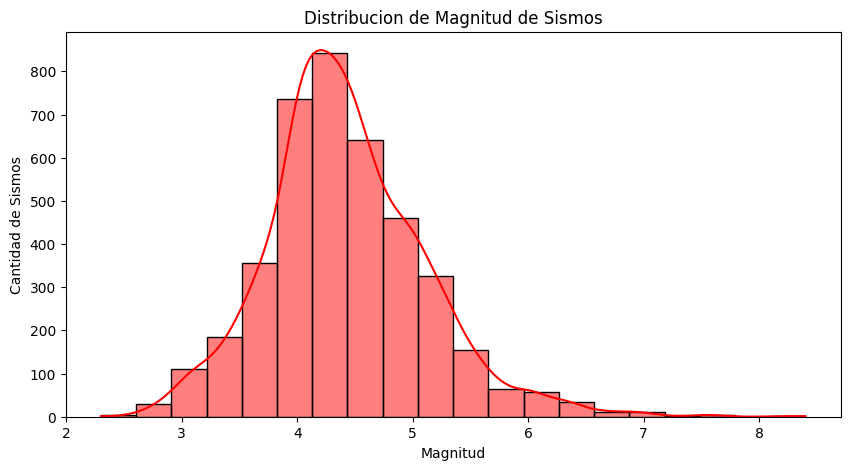

In [ ]:
#histogrma de magnitud para entender la freciencia de los sismos segun su intensidad
plt.figure(figsize=(10, 5))
sns.histplot(sismos_final['Magnitud'], bins=20, kde=True, color='red')
plt.title('Distribucion de Magnitud de Sismos')
plt.xlabel('Magnitud')
plt.ylabel('Cantidad de Sismos')
plt.show()
#kde es la densidad que suaviza los datos del histograma, nos ayuda
#a poder ver la tendencia general de la distribucion de las magnitudes.

Este grafico de dispersion nos permite evaluar si existe una correlacion entre la intensidad del sismo y su profundidad focal. En este grafico se compara la magnitud del sismo con su profundidad, podemos observar la distribuccion de los puntos, no se puede identificar un patron definido ni una linea de tendencia ya que los puntos se encuentran dispersos, esto nos da la conclusion de que la magnitud de un sismo es independiente de su profundidad.

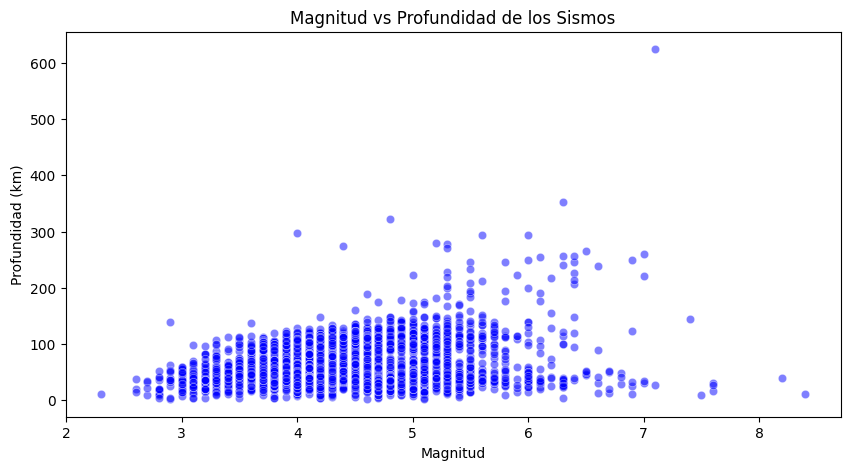

In [ ]:
#grafico de dispersion para ver si los sismos mas fuertes ocurren a mayor o menor profundidad
plt.figure(figsize=(10, 5))
sns.scatterplot(data=sismos_final, x='Magnitud', y='Profundidad', color='blue', alpha=0.5)
plt.title('Magnitud vs Profundidad de los Sismos')
plt.xlabel('Magnitud')
plt.ylabel('Profundidad (km)')
plt.show()

El grafico boxplot nos muestra que la profundidad de los sismo no son uniforme a lo largo del pais. Las regiones del norte (Arica y Antofagasta) esos eventos presentan una mayor profundidad media,y en otras regiones del sur como Magallanes los sismos son de manera superficial y tambien en el mar se presentan ocasionalmente eventos de gran profundidad.

/tmp/ipykernel_17529/146889960.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sismos_final, x='Region', y='Profundidad', palette='viridis')


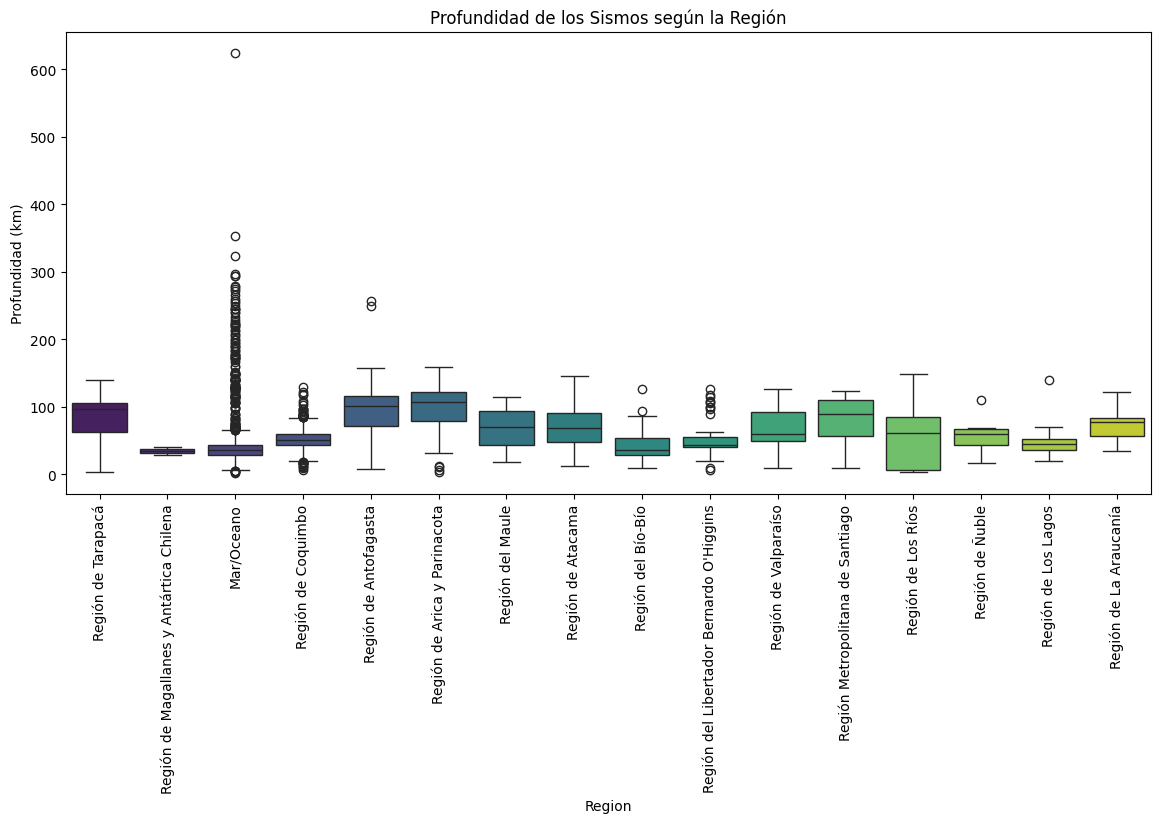

In [ ]:
#grafico boxplot para comprar varias categorias al mismo tiempo y detectar posibles "outliers"
plt.figure(figsize=(14, 6))
sns.boxplot(data=sismos_final, x='Region', y='Profundidad', palette='viridis')
plt.title('Profundidad de los Sismos según la Región')
plt.xticks(rotation=90) # Rotamos las etiquetas para que se lean bien
plt.ylabel('Profundidad (km)')
plt.show()

# OneHot Encoder y Binary Encoder

In [ ]:
pip install category_encoders

Aqui porcedemos a hacer el primer encoder, el one hot encoder para la columna de región

In [ ]:
from category_encoders import OneHotEncoder

onecoder = OneHotEncoder()
region_coded = onecoder.fit_transform(sismos_final[['Region']])
# Convertimos el resultado en un dataframe
gdf_regiones = pd.DataFrame(
    region_coded,
    columns=onecoder.get_feature_names_out(['Region']),
    index=sismos_final.index
)

Tambien hicimos el binary encoder para las comunas, eliminamos las columnas origninales para dejar las nuevas

In [ ]:
import category_encoders as ce

# Hacemos un binary Encoding para 'Comuna' usando category encoders
be = ce.BinaryEncoder(cols=['Comuna'])
df_binary = be.fit_transform(sismos_final[['Comuna']])

# Concatenamos todo y eliminamos las columnas originales
# Seleccionamos las columnas numéricas y temporales de sismos_final y eliminamos las columnas originales 'Región', 'Comuna' y 'geometría'.
df_base = sismos_final.drop(columns=['Region', 'Comuna', 'geometry'])

# Concatenate the base features with one-hot encoded regions (gdf_regiones) and binary encoded comunas (df_binary).Concatenamos las características base con el one-hot encoder y el binary encoder.
# Nos aseguramos de que los índices estén alineados antes de la concatenación.
df_final_encoded = pd.concat([
    df_base.reset_index(drop=True),
    gdf_regiones.reset_index(drop=True), # gdf_regiones es el dataframe con el one-hote encoder
    df_binary.reset_index(drop=True)
], axis=1)

print(df_final_encoded.head())
print(f"Total de columnas tras el mapeo: {len(df_final_encoded.columns)}")

        Fecha      Hora  Magnitud  Latitud  Longitud  Profundidad  Region_1  \
0  2025-05-26  03:50:27       5.6   -19.63    -69.49           97         1   
1  2025-05-13  00:47:58       5.1   -51.25    -72.28           28         0   
2  2025-05-05  09:46:48       5.0   -29.49    -71.84           48         0   
3  2025-05-05  02:17:48       5.1   -31.89    -70.88           88         0   
4  2025-05-02  15:23:49       5.8   -27.52    -72.48           30         0   

   Region_2  Region_3  Region_4  ...  Region_15  Region_16  Comuna_0  \
0         0         0         0  ...          0          0         0   
1         1         0         0  ...          0          0         0   
2         0         1         0  ...          0          0         0   
3         0         0         1  ...          0          0         0   
4         0         1         0  ...          0          0         0   

   Comuna_1  Comuna_2  Comuna_3  Comuna_4  Comuna_5  Comuna_6  Comuna_7  
0         0       

Ya casi terminando hicimos el proceso de estadarizar los datos, el escalamiento lo hicimos en sismos final para mostrar los resultados

In [ ]:
from sklearn.preprocessing import StandardScaler

# Definimos las columnas numéricas que tenemos que estandarizar
# Excluyendo 'Fecha', 'Hora', 'Region', 'Comuna', 'geometry' ya que no son numéricas para StandardScaler
cols_a_escalar = ['Magnitud', 'Latitud', 'Longitud', 'Profundidad']

# 2. Inicializamos el escalador
scaler = StandardScaler()

# 3. Aplicamos el escalamiento a sismos_final
# Usamos una copia para mantener la integridad de los datos originales si es necesario
df_final_esc = sismos_final.copy()
df_final_esc[cols_a_escalar] = scaler.fit_transform(sismos_final[cols_a_escalar])

# Muestra las primeras filas del DataFrame escalado para verificar
print(df_final_esc.head())
print(df_final_esc[cols_a_escalar].head())

        Fecha      Hora  Magnitud                                    Region  \
0  2025-05-26  03:50:27  1.702473                        Región de Tarapacá   
1  2025-05-13  00:47:58  0.975838  Región de Magallanes y Antártica Chilena   
2  2025-05-05  09:46:48  0.830511                                Mar/Oceano   
3  2025-05-05  02:17:48  0.975838                        Región de Coquimbo   
4  2025-05-02  15:23:49  1.993126                                Mar/Oceano   

             Comuna   Latitud  Longitud  Profundidad               geometry  
0             Huara  1.377236  1.053335     0.926921  POINT (-69.49 -19.63)  
1  Torres del Paine -3.927232 -1.106204    -0.877499  POINT (-72.28 -51.25)  
2        Mar/Oceano -0.276846 -0.765631    -0.354479  POINT (-71.84 -29.49)  
3         Salamanca -0.679462 -0.022564     0.691562  POINT (-70.88 -31.89)  
4        Mar/Oceano  0.053635 -1.261009    -0.825197  POINT (-72.48 -27.52)  
   Magnitud   Latitud  Longitud  Profundidad
0  1.702473 

Ya con los cambios hechos, procedemos a verigicar la data para hacer las matrices de correlación

In [ ]:
df_final.head()

,Fecha,Hora,Magnitud,Comuna,Latitud,Longitud,Profundidad,area_km,objectid,cir_sena,st_area_sh,codregion,st_length_,Region,geometry
0,2025-05-26,03:50:27,5.6,Huara,-19.63,-69.49,97,16866.8198,1084.0,1.0,1.886869e+10,15.0,7.505296e+05,Región de Arica y Parinacota,"POLYGON ((-69.4153 -17.6552, -69.3366 -17.7322..."
1,2025-05-13,00:47:58,5.1,Torres del Paine,-51.25,-72.28,28,42284.5674,1085.0,2.0,4.830637e+10,1.0,1.213713e+06,Región de Tarapacá,"MULTIPOLYGON (((-70.1603 -20.2107, -70.1602 -2..."
2,2025-05-05,09:46:48,5.0,Mar/Oceano,-29.49,-71.84,48,126071.4319,1086.0,3.0,1.508452e+11,2.0,2.516112e+06,Región de Antofagasta,"MULTIPOLYGON (((-70.7016 -25.8917, -70.7005 -2..."
3,2025-05-05,02:17:48,5.1,Salamanca,-31.89,-70.88,88,133053.1423,1087.0,15.0,3.581316e+11,12.0,9.049830e+07,Región de Magallanes y Antártica Chilena,"MULTIPOLYGON (((-67.3202 -55.9201, -67.2487 -5..."
4,2025-05-02,15:23:49,5.8,Mar/Oceano,-27.52,-72.48,30,106703.3773,1088.0,14.0,2.242743e+11,11.0,4.144481e+07,Región de Aysén del Gral.Ibañez del Campo,"MULTIPOLYGON (((-75.5799 -48.7589, -75.5803 -4..."


In [ ]:
df_final.describe()

,Magnitud,Latitud,Longitud,Profundidad,area_km,objectid,cir_sena,st_area_sh,codregion,st_length_
count,4032.000000,4032.000000,4032.000000,4032.000000,17.000000,17.000000,17.000000,1.700000e+01,17.000000,1.700000e+01
mean,4.428522,-27.839720,-70.850848,61.555060,44656.288029,1092.000000,7.647059,7.682654e+10,8.000000,9.458103e+06
std,0.688189,5.961752,1.292103,38.244172,40826.876942,5.049752,4.649478,9.119000e+10,5.049752,2.302917e+07
min,2.300000,-62.350000,-75.730000,2.000000,3937.432000,1084.000000,0.000000,9.306245e+09,0.000000,3.887224e+05
25%,4.000000,-31.820000,-71.590000,36.000000,16349.029900,1088.000000,4.000000,2.301475e+10,4.000000,1.074094e+06
50%,4.400000,-29.615000,-71.180000,50.000000,30321.890600,1092.000000,8.000000,4.596943e+10,8.000000,1.679609e+06
75%,4.800000,-21.505000,-70.030000,86.250000,48408.371300,1096.000000,11.000000,8.771834e+10,12.000000,2.401741e+06
max,8.400000,-11.070000,-58.390000,624.000000,133053.142300,1100.000000,15.000000,3.581316e+11,16.000000,9.049830e+07


In [ ]:
df_final_esc.drop(columns=['geometry', 'Fecha', 'Hora', 'Region', 'Comuna'], errors='ignore').corr()

,Magnitud,Latitud,Longitud,Profundidad
Magnitud,1.000000,0.088692,0.103796,0.211777
Latitud,0.088692,1.000000,0.727477,0.383838
Longitud,0.103796,0.727477,1.000000,0.668787
Profundidad,0.211777,0.383838,0.668787,1.000000


Una de las matrices que creamos es relacionada solamente con las variables numericas como la magnitud, latitud, longuitud y profundidad para así poder visualizar la disperción de una a otra.

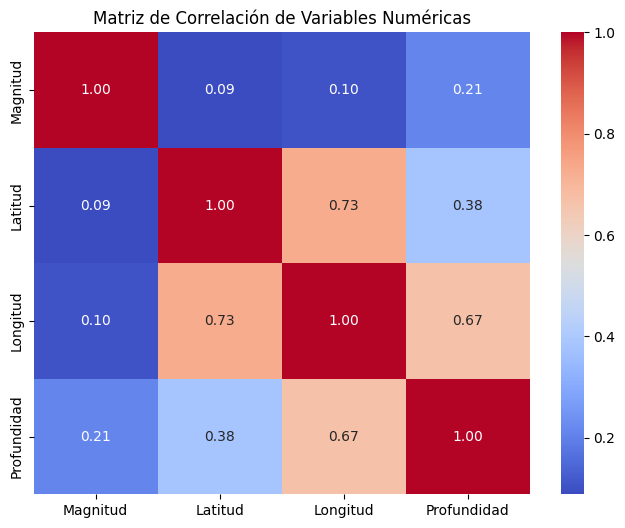

In [ ]:
# Creamos una matriz de correlación para la magnitud, latitud, longuitud y profundidad
plt.figure(figsize=(8, 6))
# Eliminamos las columnas no numericas
sns.heatmap(df_final_esc.drop(columns=['geometry', 'Fecha', 'Hora', 'Region', 'Comuna'], errors='ignore').corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación de Variables Numéricas')
plt.show()

Y la segunda matriz de correlación que creamos fue ya con las regiones y comunas, para ver como afectan los sismos tanto a las regiones como a las columnas

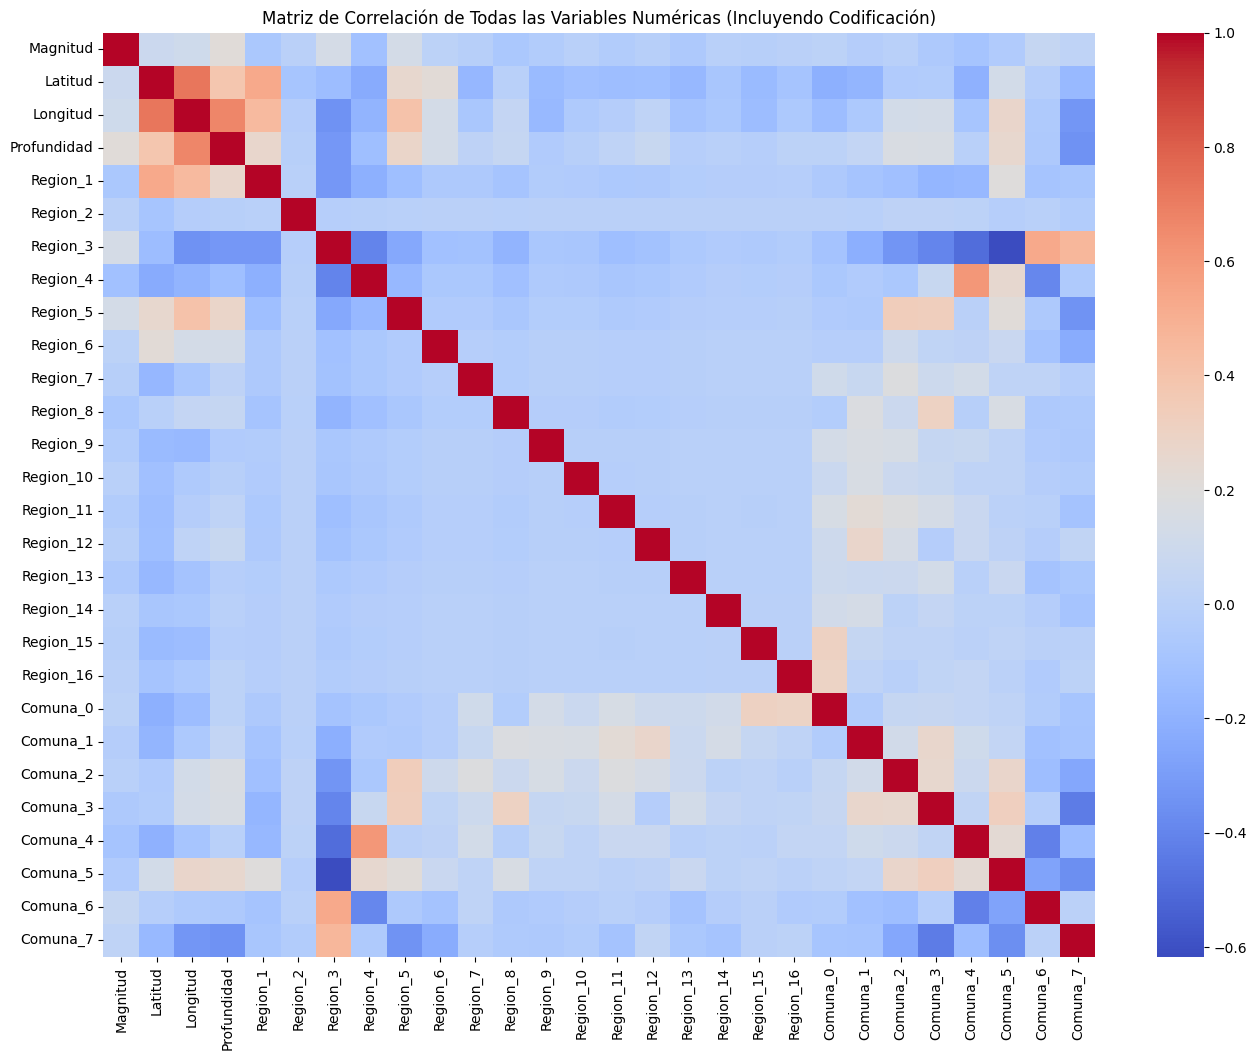

In [ ]:
# Creamos una matriz de correlación para incluyendo las comunas y regiones aparte de la magnitud, latitud, longuitud y produndidad
plt.figure(figsize=(16, 12))
# Eliminamos las columnas no numericas restantes, como fecha y hora
sns.heatmap(df_final_encoded.drop(columns=['Fecha', 'Hora'], errors='ignore').corr(), annot=False, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación de Todas las Variables Numéricas (Incluyendo Codificación)')
plt.show()